 # Customer Churn Prediction — Exploratory Data Analysis

**Objective:** Understand which customers are likely to churn from property/telecom-style features.  
**Target variable:** `churn` (`Yes` / `No`)  
**Context:** Messy customer data loaded from CSV for practicing a full EDA workflow end to end (same step pattern as the house-price EDA session).

### How to use this notebook
Work top to bottom. Each numbered step has:
1. A short **why** (purpose of the step)
2. Code that performs the step (fill every `# TODO` cell)
3. Space for insights at the end

| Step | Focus |
|------|--------|
| 1–2 | Load / inspect |
| 3–5 | Missing values, duplicates, dtypes |
| 6–7 | Summaries & outliers |
| 8 | Binning (after outliers) |
| 9–11 | Uni / bi / multivariate visuals |
| 12 | Key findings (markdown) |

**Dataset file:** `customer_churn.csv` (same folder as this notebook).

**Required names for grading:** `df`, `raw_shape`, `missing_df`, `num_cols_with_na`, `cat_cols_with_na`, `df_before_outliers`, `outliers_iqr_mask`, `age_bin`, `corr_matrix`, `multi_corr`, `top_corr_with_churn`

# **Important**:Make sure you use the same variable name mentioned above

## 0. Imports

Import numpy, pandas, matplotlib, seaborn, and display helpers.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


## 1. Load Dataset

### Why this step
EDA starts with data on disk. Load `customer_churn.csv` so the rest of the notebook mirrors a real workflow: read a file, then clean and plot.

### What the code does
1. Reads the CSV with `pd.read_csv` into **`df`**.
2. Prints shape and column names, then shows the first few rows.

In [ ]:
df = pd.read_csv("customer_churn.csv")

raw_shape = df.shape

# Print the number of rows and columns
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

# Print all column names
print("\nColumn names:")
print(df.columns.tolist())

display(df.head())


Rows: 518 | Columns: 12

Column names:
['customer_id', 'age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_tickets', 'contract_type', 'internet_service', 'payment_method', 'gender', 'partner', 'churn']


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
0,C10000,19.0,6,84.50,506.79,6,Month-to-month,Fiber optic,Credit card,Female,No,Yes
1,C10001,27.0,56,106.48,5951.56,4,Two year,No,Electronic check,Male,Yes,No
2,C10002,24.0,47,64.30,3449.02,0,One year,Fiber optic,Credit card,Female,No,No
3,C10003,NaN,32,43.28,1335.41,7,One year,Fiber optic,Credit card,Female,No,No
4,C10004,56.0,31,42.14,1266.18,3,One year,Fiber optic,Credit card,Female,No,No


## 2. Inspect the Data

### Why this step
Never clean or model blind. First look at samples and types so you know what each column is and whether missing values already appear.

### What the code does
- `head()` / `tail()`: first and last rows
- `dtypes`: int / float / object
- `info()`: non-null counts and memory

In [ ]:
# first and last few rows
display(df.head())
display(df.tail())

# data types of all columns
print("\nData types:")
print(df.dtypes)

# Detailed information about the DataFrame
print("\nInfo:")
df.info()


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
0,C10000,19.0,6,84.50,506.79,6,Month-to-month,Fiber optic,Credit card,Female,No,Yes
1,C10001,27.0,56,106.48,5951.56,4,Two year,No,Electronic check,Male,Yes,No
2,C10002,24.0,47,64.30,3449.02,0,One year,Fiber optic,Credit card,Female,No,No
3,C10003,NaN,32,43.28,1335.41,7,One year,Fiber optic,Credit card,Female,No,No
4,C10004,56.0,31,42.14,1266.18,3,One year,Fiber optic,Credit card,Female,No,No


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
513,C10084,79.0,45,NaN,1324.55,5,Month-to-month,DSL,Electronic check,Female,Yes,Yes
514,C10371,36.0,48,67.95,3486.47,2,Two year,DSL,Mailed check,Male,No,No
515,C10388,44.0,65,96.92,5779.48,6,Month-to-month,Fiber optic,Credit card,Male,Yes,No
516,C10495,52.0,30,67.93,1787.24,7,Month-to-month,DSL,Credit card,Female,Yes,Yes
517,C10030,46.0,32,22.43,765.80,4,One year,DSL,Bank transfer,Female,Yes,No



Data types:
customer_id                str
age                    float64
tenure_months            int64
monthly_charges        float64
total_charges          float64
num_support_tickets      int64
contract_type              str
internet_service           str
payment_method             str
gender                     str
partner                    str
churn                      str
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          518 non-null    str    
 1   age                  489 non-null    float64
 2   tenure_months        518 non-null    int64  
 3   monthly_charges      494 non-null    float64
 4   total_charges        498 non-null    float64
 5   num_support_tickets  518 non-null    int64  
 6   contract_type        502 non-null    str    
 7   internet_service     504 non-null    str    


## 3. Handle Missing Values

### Why this step
Models and many aggregations fail or become biased when NaNs remain. Find gaps first, then choose a fill strategy that matches each column type.

### 3a. Count nulls
Create **`missing_df`** with columns `Missing` and `Percent`, filtered to columns that have nulls, sorted descending.

In [5]:
# Count the number of missing values in each column
missing = df.isnull().sum()

# Calculate the percentage of missing values in each column
missing_pct = (missing / len(df) * 100).round(2)

# Create a DataFrame containing the missing-value counts and percentages
missing_df = pd.DataFrame({
    "Missing": missing,
    "Percent": missing_pct
})

# Keep only columns with missing values and sort them from highest to lowest
missing_df = missing_df[missing_df["Missing"] > 0].sort_values(
    "Missing",
    ascending=False
)

# Display the missing-value summary
print(missing_df)


                  Missing  Percent
age                    29     5.60
monthly_charges        24     4.63
total_charges          20     3.86
contract_type          16     3.09
internet_service       14     2.70


### 3b. Inspect numeric missing values (skew → mean vs median)

For skewed numerics prefer **median**; for roughly symmetric prefer **mean**.

Print **`num_cols_with_na`** and **`cat_cols_with_na`**.  
Plot a histogram for a skewed numeric column with nulls (e.g. `monthly_charges`) and print mean / median / mode.

C:\Users\subranshu.p\AppData\Local\Temp\ipykernel_20956\4142508152.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = df.select_dtypes(include=["object"])


Numeric cols with NA: ['age', 'monthly_charges', 'total_charges']
Categorical cols with NA: ['contract_type', 'internet_service']

monthly_charges statistics:
Mean: 80.31
Median: 70.56
Mode: 450.0
Skewness: 6.42


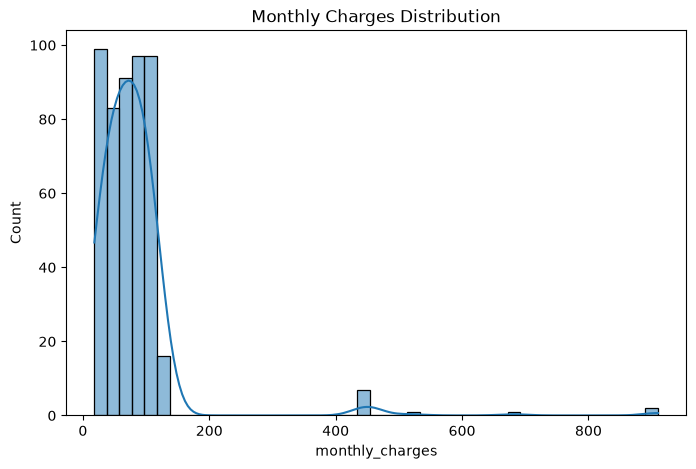

In [6]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=[np.number])

# Find numerical columns that contain missing values
num_cols_with_na = numeric_df.columns[
    numeric_df.isnull().any()
]

# Select only categorical columns
categorical_df = df.select_dtypes(include=["object"])

# Find categorical columns that contain missing values
cat_cols_with_na = categorical_df.columns[
    categorical_df.isnull().any()
]

# Print columns containing missing values
print("Numeric cols with NA:", list(num_cols_with_na))
print("Categorical cols with NA:", list(cat_cols_with_na))

# Inspect monthly_charges without the missing values
s = df["monthly_charges"].dropna()

# Print important statistics
print("\nmonthly_charges statistics:")
print("Mean:", round(s.mean(), 2))
print("Median:", round(s.median(), 2))
print("Mode:", round(s.mode().iloc[0], 2))
print("Skewness:", round(s.skew(), 2))

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(s, kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("monthly_charges")
plt.ylabel("Count")
plt.show()

### 3c. Inspect categorical missing values

For each categorical column with nulls, print the **mode** and **unique values**.

In [7]:
# Inspect each categorical column containing missing values
for col in cat_cols_with_na:

    # Print the column name
    print(f"\n{col}:")

    # Print the most frequently occurring category
    print("Mode:", df[col].mode().iloc[0])

    # Print all unique values present in the column
    print("Unique values:", df[col].unique())



contract_type:
Mode: Month-to-month
Unique values: <StringArray>
['Month-to-month', 'Two year', 'One year', nan]
Length: 4, dtype: str

internet_service:
Mode: Fiber optic
Unique values: <StringArray>
['Fiber optic', 'No', 'DSL', nan]
Length: 4, dtype: str


### 3d. Fill missing values

Fill in place on **`df`**:
- Numeric: **median** when `|skew| > 0.5`, else **mean**
- Categorical: **mode**
- Any leftover numeric NaNs: `ffill` then `bfill`
- Verify remaining missing count is **0**

In [8]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=[np.number])

# Find numerical columns that contain missing values
num_cols_with_na = numeric_df.columns[
    numeric_df.isnull().any()
]

# Select only categorical columns
categorical_df = df.select_dtypes(include=["object"])

# Find categorical columns that contain missing values
cat_cols_with_na = categorical_df.columns[
    categorical_df.isnull().any()
]

print("Numeric cols with NA:", list(num_cols_with_na))
print("Categorical cols with NA:", list(cat_cols_with_na))


# Fill numerical missing values based on skewness
for col in num_cols_with_na:

    # Calculate skewness using non-missing values
    skew_v = df[col].dropna().skew()

    # Use median for skewed data, otherwise use mean
    if abs(skew_v) > 0.5:
        fill_value = df[col].median()
        method = "MEDIAN"
    else:
        fill_value = df[col].mean()
        method = "MEAN"

    # Fill the missing values
    df[col] = df[col].fillna(fill_value)

    print(
        col,
        "| Skewness =", round(skew_v, 2),
        "| Filled with", method,
        "=", round(fill_value, 2)
    )


# Fill categorical missing values using mode
for col in cat_cols_with_na:

    # Find the most frequently occurring category
    mode_value = df[col].mode().iloc[0]

    # Fill the missing values
    df[col] = df[col].fillna(mode_value)

    print(col, "filled with MODE =", mode_value)


# Fill any leftover numerical missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].ffill().bfill()


# Verify that no missing values remain
print("\nRemaining missing values:", df.isnull().sum().sum())



Numeric cols with NA: ['age', 'monthly_charges', 'total_charges']
Categorical cols with NA: ['contract_type', 'internet_service']
age | Skewness = 0.06 | Filled with MEAN = 47.75
monthly_charges | Skewness = 6.42 | Filled with MEDIAN = 70.56
total_charges | Skewness = 6.43 | Filled with MEDIAN = 1981.05
contract_type filled with MODE = Month-to-month
internet_service filled with MODE = Fiber optic

Remaining missing values: 0


C:\Users\subranshu.p\AppData\Local\Temp\ipykernel_20956\2739113708.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = df.select_dtypes(include=["object"])


## 4. Duplicate Records

### Why this step
Exact duplicate rows overweight the same customer in averages, correlations, and model training.

### What the code does
Count duplicates with `duplicated()`, then remove them with `drop_duplicates()` and reset the index.

In [9]:
# Count duplicate rows
n_dupes = df.duplicated().sum()

print("Duplicate rows:", n_dupes)

# Remove duplicate rows and reset the index
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after dropping duplicates:", df.shape)


Duplicate rows: 18
Shape after dropping duplicates: (500, 12)


### Check remaining nulls

Re-check before type casting. If any null rows remain, drop them.

In [10]:
# Display columns that still contain missing values
print("Nulls per column before final cleanup:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Store the number of rows before final null cleanup
rows_before = len(df)

# Count rows containing at least one missing value
null_rows = df.isnull().any(axis=1).sum()

print("\nRows with at least one null:", null_rows)

# Drop rows only if any null values still remain
if null_rows > 0:
    df = df.dropna().reset_index(drop=True)
    print("Dropped", rows_before - len(df), "rows with remaining nulls.")
else:
    print("No remaining nulls - nothing to drop.")

# Verify the DataFrame after the null check
print("Shape after null check:", df.shape)
print("Total nulls now:", df.isnull().sum().sum())


Nulls per column before final cleanup:
Series([], dtype: int64)

Rows with at least one null: 0
No remaining nulls - nothing to drop.
Shape after null check: (500, 12)
Total nulls now: 0


## 5. Convert Data Types

### Why this step
Correct types unlock groupbys and integer summaries. Wrong types (e.g. labels as plain object only) make analysis harder.

### What the code does
- Cast label columns to `category`
- Cast whole-number-ish numerics to int where safe
- Create **`churn_flag`** (Yes→1, No→0) for later correlation

Binning comes **after** outlier handling (Step 8).

In [11]:
# Display data types before conversion
print("Before conversions:\n")
print(df.dtypes)


# List columns containing categorical labels
cat_cols = [
    "contract_type",
    "internet_service",
    "payment_method",
    "gender",
    "partner",
    "churn"
]

# Convert categorical label columns to category data type
for c in cat_cols:
    df[c] = df[c].astype("category")


# List numerical columns that should contain whole numbers
int_cols = [
    "age",
    "tenure_months",
    "num_support_tickets"
]

# Convert whole-number columns to integer data type
for c in int_cols:
    df[c] = df[c].round().astype(int)


# Create a numerical version of churn for correlation analysis
df["churn_flag"] = df["churn"].map({
    "Yes": 1,
    "No": 0
}).astype(int)


# Display data types after conversion
print("\nAfter conversions:\n")
print(df.dtypes)

# Display churn and churn_flag together
display(df[["churn", "churn_flag"]].head())


Before conversions:

customer_id                str
age                    float64
tenure_months            int64
monthly_charges        float64
total_charges          float64
num_support_tickets      int64
contract_type              str
internet_service           str
payment_method             str
gender                     str
partner                    str
churn                      str
dtype: object

After conversions:

customer_id                 str
age                       int64
tenure_months             int64
monthly_charges         float64
total_charges           float64
num_support_tickets       int64
contract_type          category
internet_service       category
payment_method         category
gender                 category
partner                category
churn                  category
churn_flag                int64
dtype: object


,churn,churn_flag
0,Yes,1
1,No,0
2,No,0
3,No,0
4,No,0


## 6. Summary Statistics

### Why this step
Summaries describe center, spread, and range before plotting. Large mean–median gaps hint at skew.

### What the code does
- `describe()` for numerics
- Mean / median / mode table for skewed columns
- Value counts for key categoricals

In [ ]:
# Select all numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns


# ---------------- NUMERICAL SUMMARY ----------------

# Display descriptive statistics for numerical columns
display(df[num_cols].describe().T.round(2))


# ---------------- MEAN, MEDIAN AND MODE ----------------

# Select numerical columns that are noticeably skewed
skewed_cols = [
    "monthly_charges",
    "total_charges"
]

# Create a summary table for the skewed columns
skewed_summary = pd.DataFrame({
    "Mean": df[skewed_cols].mean(),
    "Median": df[skewed_cols].median(),
    "Mode": df[skewed_cols].mode().iloc[0]
}).round(2)

print("\nMean, Median and Mode for skewed columns:")
display(skewed_summary)


# ---------------- CATEGORICAL SUMMARY ----------------

print("\nCategorical value counts:")

# Display frequency counts for important categorical columns
for c in ["contract_type", "internet_service", "churn"]:

    print("\n", c, ":")
    print(df[c].value_counts())


,count,mean,std,min,25%,50%,75%,max
age,500.0,47.82,17.55,18.00,33.0,48.00,63.00,79.00
tenure_months,500.0,35.94,20.87,0.00,19.0,36.00,54.00,72.00
monthly_charges,500.0,80.29,82.00,18.13,47.0,70.56,96.80,910.00
total_charges,500.0,2950.67,4085.73,25.68,995.1,1981.05,3683.04,51511.12
num_support_tickets,500.0,3.42,2.29,0.00,1.0,3.00,5.00,7.00
churn_flag,500.0,0.47,0.50,0.00,0.0,0.00,1.00,1.00



Mean, Median and Mode for skewed columns:


,Mean,Median,Mode
monthly_charges,80.29,70.56,70.56
total_charges,2950.67,1981.05,1981.05



Categorical value counts:

 contract_type :
contract_type
Month-to-month    300
One year          106
Two year           94
Name: count, dtype: int64

 internet_service :
internet_service
Fiber optic    240
DSL            157
No             103
Name: count, dtype: int64

 churn :
churn
No     266
Yes    234
Name: count, dtype: int64


## 7. Detect Outliers (IQR & Z-score)

### Why this step
Extreme `monthly_charges` can distort means and correlations. Detect candidates, then **cap (winsorize)** like the house-price notebook (keep rows, reduce extreme pull).

### What the code does
1. Save **`df_before_outliers`**
2. Box plots + IQR / Z-score counts
3. Build **`outliers_iqr_mask`** for `monthly_charges`
4. Cap `monthly_charges` (and `total_charges`) at IQR fences

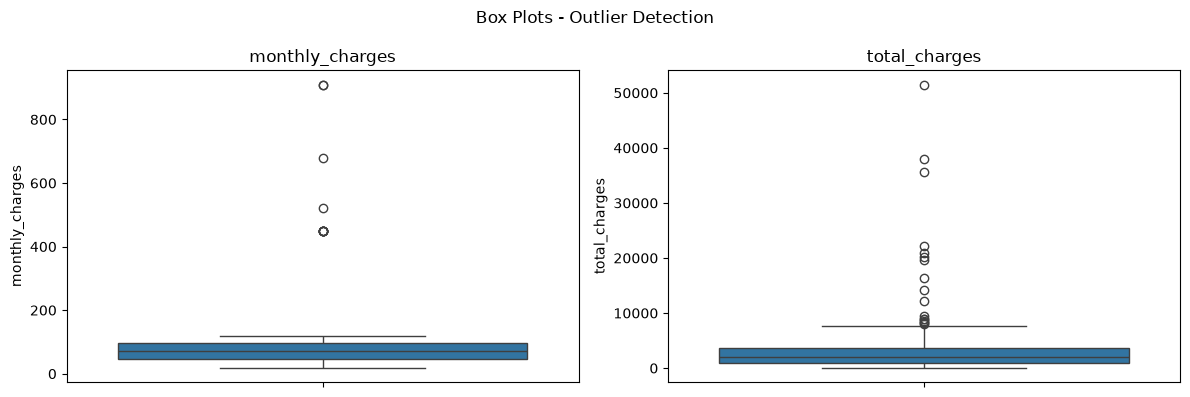

monthly_charges | IQR outliers = 11 | Lower fence = -27.69 | Upper fence = 171.49 | Z-score outliers = 11
total_charges | IQR outliers = 17 | Lower fence = -3036.83 | Upper fence = 7714.96 | Z-score outliers = 8

Monthly charges IQR outliers before capping: 11
Monthly charges capped between: -27.69 and 171.49
Total charges capped between: -3036.83 and 7714.96

Shape before outlier handling: (500, 13)
Shape after outlier handling: (500, 13)

Skewness after capping:
monthly_charges: 0.44
total_charges: 0.99


In [13]:
# Save a copy of the DataFrame before handling outliers
df_before_outliers = df.copy()


# Define a function to find outliers using the IQR method
def iqr_outliers(series):

    # Calculate Q1 and Q3
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    # Calculate IQR
    iqr = q3 - q1

    # Calculate lower and upper fences
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Mark values outside the fences as outliers
    mask = (series < lower) | (series > upper)

    # Return the mask and fence values
    return mask, lower, upper


# Columns to check for outliers
outlier_cols = [
    "monthly_charges",
    "total_charges"
]


# ---------------- BOX PLOTS ----------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.suptitle("Box Plots - Outlier Detection")
plt.tight_layout()
plt.show()


# ---------------- IQR AND Z-SCORE COUNTS ----------------

for col in outlier_cols:

    # Find outliers using IQR
    mask, lower, upper = iqr_outliers(df[col])

    # Calculate Z-scores
    z = np.abs(
        (df[col] - df[col].mean()) / df[col].std()
    )

    # Display the number of outliers
    print(
        col,
        "| IQR outliers =", mask.sum(),
        "| Lower fence =", round(lower, 2),
        "| Upper fence =", round(upper, 2),
        "| Z-score outliers =", (z > 3).sum()
    )


# ---------------- MONTHLY CHARGES IQR MASK ----------------

# Required variable for the assignment
outliers_iqr_mask, monthly_lower, monthly_upper = iqr_outliers(
    df["monthly_charges"]
)


# ---------------- TOTAL CHARGES IQR FENCES ----------------

total_mask, total_lower, total_upper = iqr_outliers(
    df["total_charges"]
)


# ---------------- CAP OUTLIERS ----------------

# Cap monthly_charges at its IQR fences
df["monthly_charges"] = df["monthly_charges"].clip(
    lower=monthly_lower,
    upper=monthly_upper
)

# Cap total_charges at its IQR fences
df["total_charges"] = df["total_charges"].clip(
    lower=total_lower,
    upper=total_upper
)


# ---------------- VERIFY ----------------

print("\nMonthly charges IQR outliers before capping:",
      outliers_iqr_mask.sum())

print(
    "Monthly charges capped between:",
    round(monthly_lower, 2),
    "and",
    round(monthly_upper, 2)
)

print(
    "Total charges capped between:",
    round(total_lower, 2),
    "and",
    round(total_upper, 2)
)

print("\nShape before outlier handling:", df_before_outliers.shape)
print("Shape after outlier handling:", df.shape)

print("\nSkewness after capping:")
print("monthly_charges:", round(df["monthly_charges"].skew(), 2))
print("total_charges:", round(df["total_charges"].skew(), 2))


## 8. Binning

### Why this step
After outliers are handled, turn continuous fields into interpretable categories for group analysis (same idea as engineered features in the house-price EDA session).

### What the code does
Create **`age_bin`** and `tenure_bin`, then show value counts.

In [15]:
# Create age groups using fixed age ranges
age_bin = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, np.inf],
    labels=["Young", "Adult", "Middle-aged", "Senior"]
)

# Add age_bin to the DataFrame
df["age_bin"] = age_bin


# Create tenure groups using fixed month ranges
tenure_bin = pd.cut(
    df["tenure_months"],
    bins=[-1, 12, 24, 48, np.inf],
    labels=["New", "Short-term", "Medium-term", "Long-term"]
)

# Add tenure_bin to the DataFrame
df["tenure_bin"] = tenure_bin


# Display the number of customers in each age group
print("Age bin counts:")
print(df["age_bin"].value_counts().sort_index())


# Display the number of customers in each tenure group
print("\nTenure bin counts:")
print(df["tenure_bin"].value_counts().sort_index())


Age bin counts:
age_bin
Young          109
Adult          110
Middle-aged    142
Senior         139
Name: count, dtype: int64

Tenure bin counts:
tenure_bin
New             94
Short-term      79
Medium-term    163
Long-term      164
Name: count, dtype: int64


## 9. Univariate Analysis

### Why this step
Study **one variable at a time** first — shape, typical ranges, and category balance — before relating variables to each other.

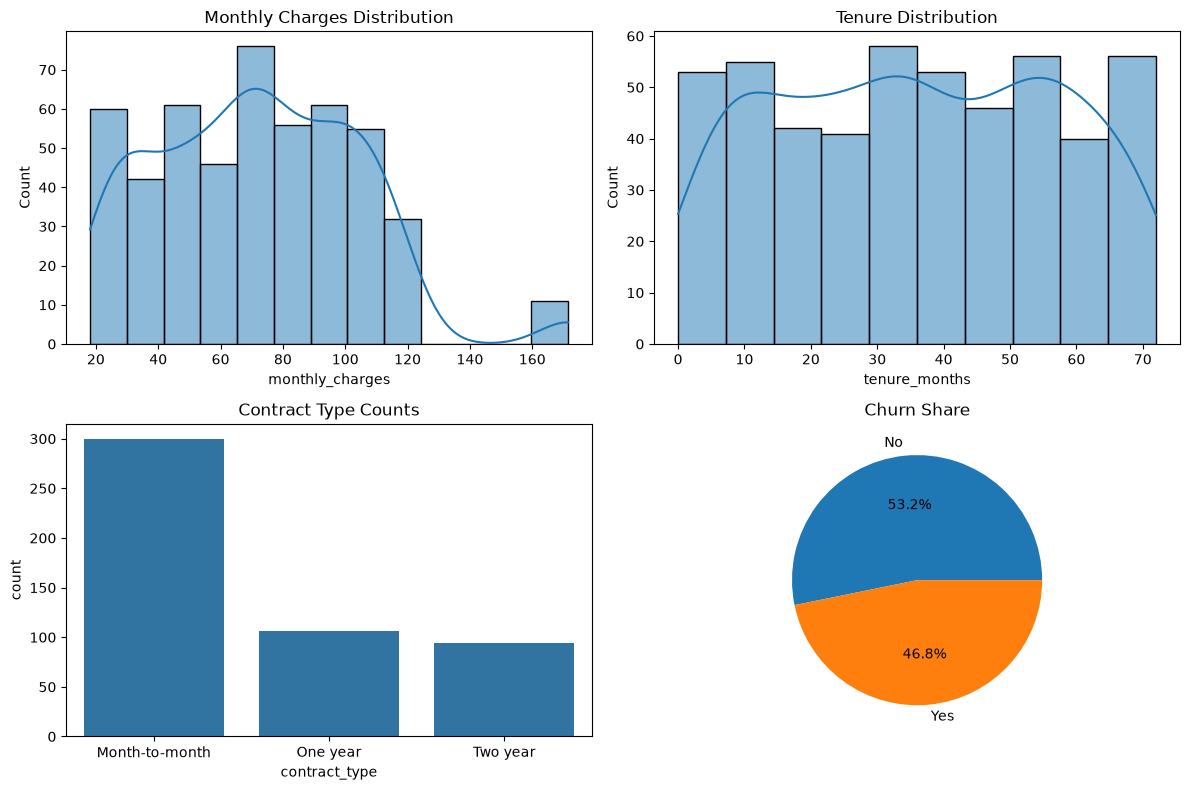

In [ ]:
# Univariate Analysis = study ONE variable at a time. 
# Here I am not analyzing all variables (Query?)

# Create a 2 x 2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


# 1) Monthly charges histogram with KDE
sns.histplot(
    df["monthly_charges"],
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Monthly Charges Distribution")


# 2) Tenure months histogram with KDE
sns.histplot(
    df["tenure_months"],
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Tenure Distribution")


# 3) Contract type count plot
sns.countplot(
    data=df,
    x="contract_type",
    order=["Month-to-month", "One year", "Two year"],
    ax=axes[1, 0]
)

axes[1, 0].set_title("Contract Type Counts")


# 4) Churn pie chart
df["churn"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ax=axes[1, 1],
    ylabel=""
)

axes[1, 1].set_title("Churn Share")


# Adjust spacing between plots
plt.tight_layout()

# Display all plots
plt.show()


## 10. Bivariate Analysis

### Why this step
Bivariate = relationship between **two** variables — where you find predictors of `churn`.

Split by types:
- **Numerical vs Numerical** — scatter / correlation
- **Numerical vs Categorical** — box / violin / bar
- **Categorical vs Categorical** — crosstab / stacked bar / heatmap

### Numerical vs Numerical

Scatter plots and Pearson correlation with `churn_flag`.

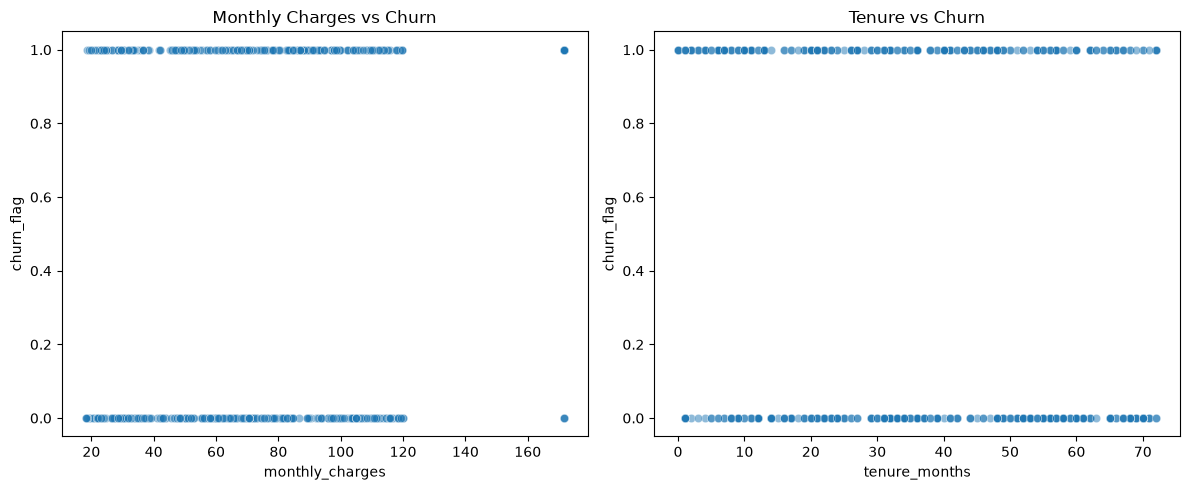


Pearson correlations with churn_flag:
num_support_tickets    0.199
monthly_charges        0.057
age                    0.047
total_charges         -0.087
tenure_months         -0.160
Name: churn_flag, dtype: float64


In [ ]:
# Select all numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns


# Create the correlation matrix
corr_matrix = df[num_cols].corr()


# Create two side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Monthly charges vs churn flag
sns.scatterplot(
    data=df,
    x="monthly_charges",
    y="churn_flag",
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Monthly Charges vs Churn")


# Tenure months vs churn flag
sns.scatterplot(
    data=df,
    x="tenure_months",
    y="churn_flag",
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title("Tenure vs Churn")


# Adjust spacing and display plots
plt.tight_layout()
plt.show()


# Display Pearson correlations with churn_flag
print("\nPearson correlations with churn_flag:")

print(
    corr_matrix["churn_flag"]
    .drop("churn_flag")
    .sort_values(ascending=False)
    .round(3)
)


### Numerical vs Categorical

Compare charges / tenure across churn and contract groups.

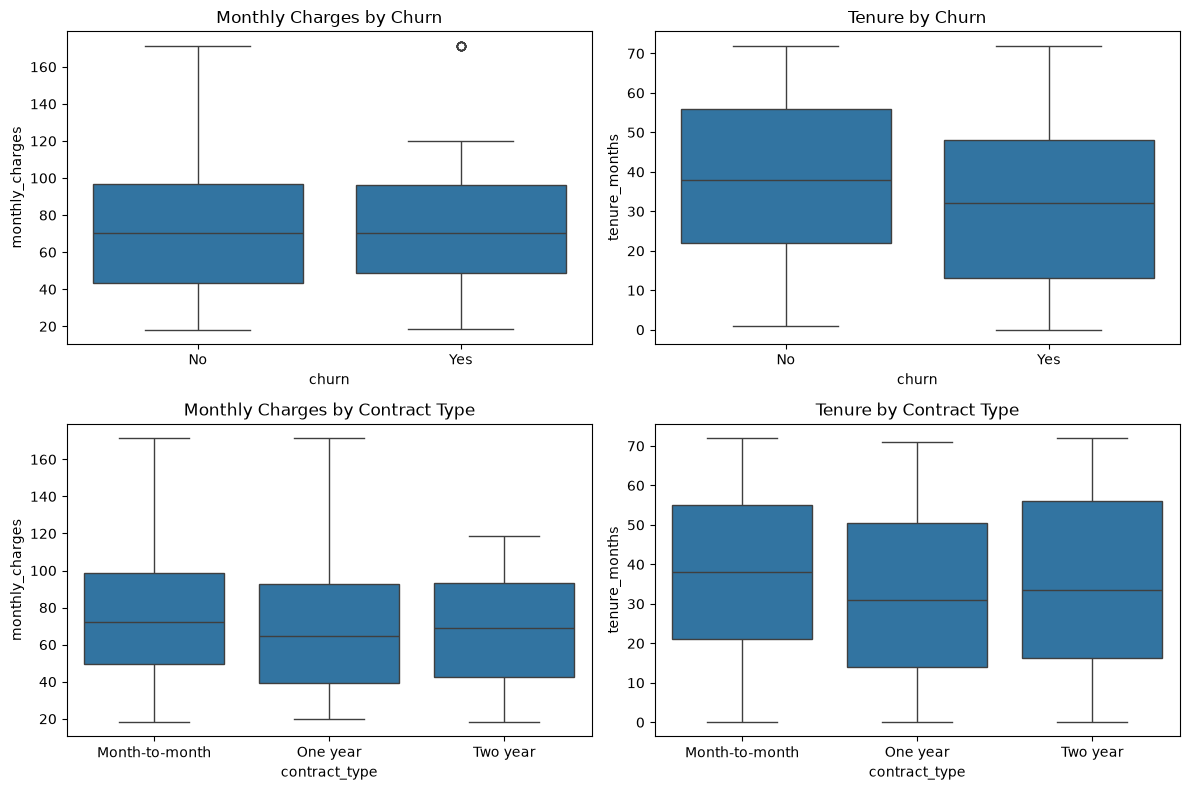

In [ ]:
# Numerical vs Categorical Analysis

# Create a 2 x 2 grid of box plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


# 1) Monthly charges across churn groups
sns.boxplot(
    data=df,
    x="churn",
    y="monthly_charges",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Monthly Charges by Churn")


# 2) Tenure across churn groups
sns.boxplot(
    data=df,
    x="churn",
    y="tenure_months",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Tenure by Churn")


# 3) Monthly charges across contract groups
sns.boxplot(
    data=df,
    x="contract_type",
    y="monthly_charges",
    order=["Month-to-month", "One year", "Two year"],
    ax=axes[1, 0]
)

axes[1, 0].set_title("Monthly Charges by Contract Type")


# 4) Tenure across contract groups
sns.boxplot(
    data=df,
    x="contract_type",
    y="tenure_months",
    order=["Month-to-month", "One year", "Two year"],
    ax=axes[1, 1]
)

axes[1, 1].set_title("Tenure by Contract Type")


# Adjust spacing between plots
plt.tight_layout()

# Display all plots
plt.show()


### Categorical vs Categorical

Crosstabs, stacked bars, and heatmaps for category mixes vs churn.

Contract Type vs Churn - Counts:


churn,No,Yes
contract_type,,
Month-to-month,109,191
One year,75,31
Two year,82,12



Contract Type vs Churn - Percentages:


churn,No,Yes
contract_type,,
Month-to-month,36.33,63.67
One year,70.75,29.25
Two year,87.23,12.77


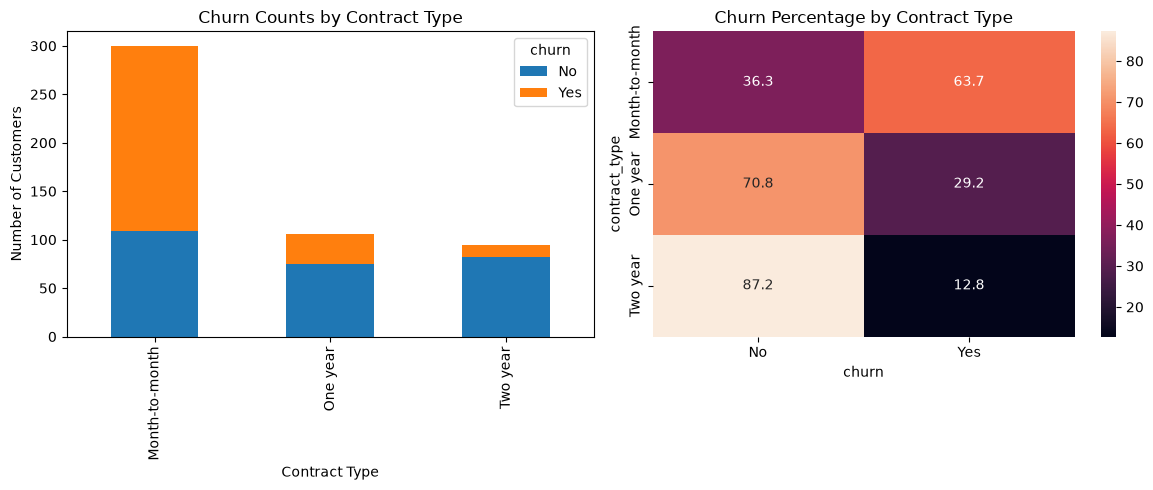

In [ ]:
# Categorical vs Categorical Analysis

# Create a crosstab of contract type and churn
contract_churn = pd.crosstab(
    df["contract_type"],
    df["churn"]
)

print("Contract Type vs Churn - Counts:")
display(contract_churn)


# Calculate row-wise percentages
contract_churn_pct = pd.crosstab(
    df["contract_type"],
    df["churn"],
    normalize="index"
) * 100

print("\nContract Type vs Churn - Percentages:")
display(contract_churn_pct.round(2))


# Create two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Stacked bar chart
contract_churn.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("Churn Counts by Contract Type")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Number of Customers")


# Heatmap of row percentages
sns.heatmap(
    contract_churn_pct,
    annot=True,
    fmt=".1f",
    ax=axes[1]
)

axes[1].set_title("Churn Percentage by Contract Type")


# Adjust spacing
plt.tight_layout()

# Display plots
plt.show()


## 11. Multivariate Analysis

### Why this step
Look at **three or more** signals together — closer to how churn really works (tenure + charges + tickets, etc.).

1. **Heatmap** — many numeric correlations at once (`multi_corr`)
2. **Bubble chart** — scatter with size + color

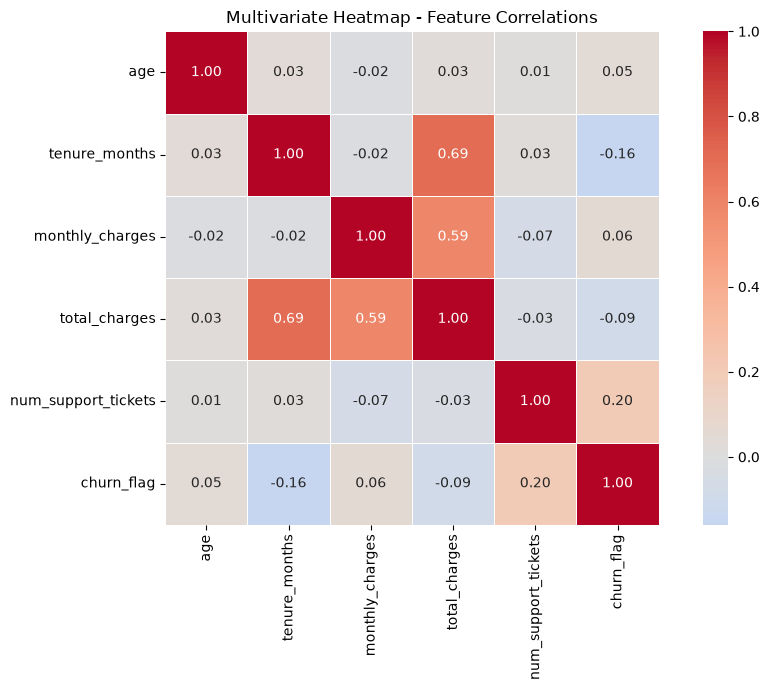

Strongest absolute correlations with churn:
num_support_tickets    0.199
tenure_months          0.160
total_charges          0.087
monthly_charges        0.057
age                    0.047
Name: churn_flag, dtype: float64


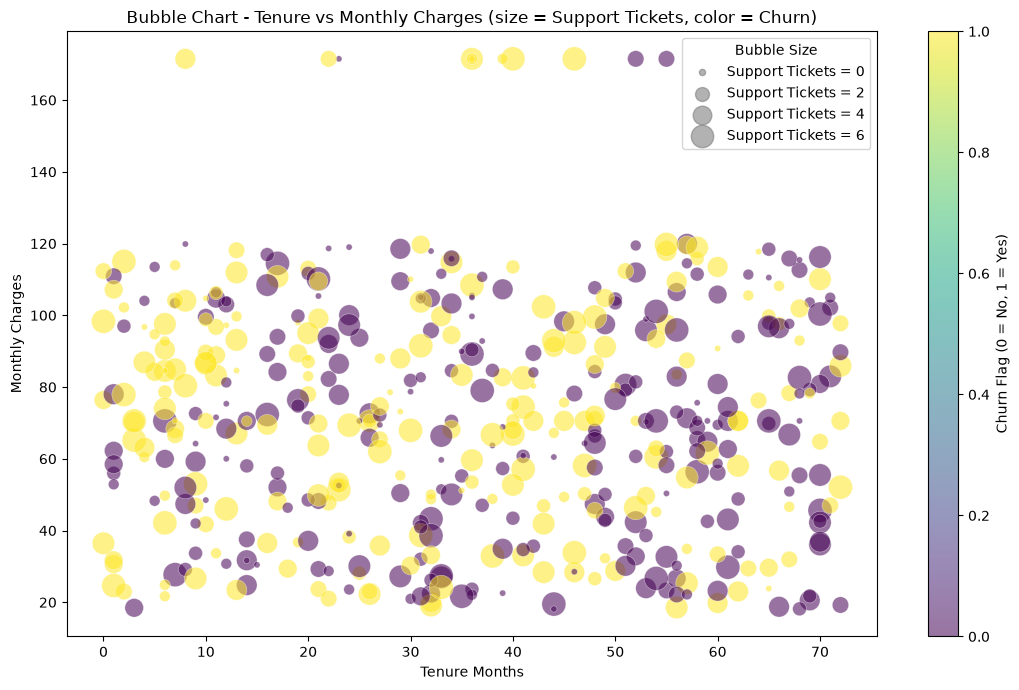

In [ ]:
# ---------------- MULTIVARIATE ANALYSIS ----------------


# Select important numerical columns
multi_cols = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_tickets",
    "churn_flag"
]


# ---------------- CORRELATION HEATMAP ----------------

# Calculate Pearson correlation between all selected numerical columns
multi_corr = df[multi_cols].corr()


# Create the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    multi_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4
)

plt.title("Multivariate Heatmap - Feature Correlations")
plt.tight_layout()
plt.show()


# Rank numerical features by absolute correlation with churn
top_corr_with_churn = (
    multi_corr["churn_flag"]
    .drop("churn_flag")
    .abs()
    .sort_values(ascending=False)
)

print("Strongest absolute correlations with churn:")
print(top_corr_with_churn.round(3))


# ---------------- BUBBLE CHART ----------------

# Use a copy of the data for plotting
plot_df = df.copy()


# Create one figure
fig, ax = plt.subplots(figsize=(11, 7))


# Create the bubble chart
scatter = ax.scatter(
    x=plot_df["tenure_months"],
    y=plot_df["monthly_charges"],
    s=plot_df["num_support_tickets"] * 40 + 20,
    c=plot_df["churn_flag"],
    cmap="viridis",
    alpha=0.55,
    edgecolors="white",
    linewidths=0.4
)


# Add color bar for churn
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Churn Flag (0 = No, 1 = Yes)")


# Add bubble-size legend for support tickets
for tickets, marker_size in [(0, 20), (2, 100), (4, 180), (6, 260)]:
    ax.scatter(
        [],
        [],
        s=marker_size,
        c="gray",
        alpha=0.6,
        label="Support Tickets = " + str(tickets)
    )

ax.legend(
    title="Bubble Size",
    loc="upper right"
)


# Add labels and title
ax.set_xlabel("Tenure Months")
ax.set_ylabel("Monthly Charges")

ax.set_title(
    "Bubble Chart - Tenure vs Monthly Charges "
    "(size = Support Tickets, color = Churn)"
)


# Adjust spacing and display
plt.tight_layout()
plt.show()


## 12. KEY FINDINGS — answer in markdown

This is the **final step**. Write 2–4 sentences for each question based on what you observed above.

### Q1. Which numeric features are most correlated with `churn_flag`? What does that imply?
### Q2. After the skew check, did you prefer mean or median for any fills? Why?
### Q3. Which segments (contract, age bin, tickets) look most associated with churn?
### Q4. Why cap outliers instead of deleting rows here?
### Q5. What risk remains before training a churn classifier?

### Your Answers


**Q1: Which numeric features are most correlated with `churn_flag`? What does that imply?**

- `num_support_tickets` has the strongest positive correlation with churn (`+0.199`).
- `tenure_months` has the strongest negative correlation with churn (`-0.160`), suggesting longer-tenure customers tend to churn less.
- All correlations are weak, so no single numerical feature strongly explains churn.
- Reference: Section 11 – Multivariate Analysis

---

**Q2: After the skew check, did you prefer mean or median for any fills? Why?**

- `age` used the mean because its skewness was very low (`0.06`), so its distribution was roughly symmetric.
- `monthly_charges` and `total_charges` used the **median** because they were strongly skewed.
- Median is preferred for skewed data because extreme values can pull the mean.
- Reference: Section 3d – Fill Missing Values, which specifies median for `|skew| > 0.5`, otherwise mean.

---

**Q3: Which segments (contract, age bin, tickets) look most associated with churn?**

- `Contract` shows the clearest association: Month-to-month customers had about 63.7% churn, compared with 29.2% for one-year and 12.8% for two-year contracts.
- `num_support_tickets` also shows a weak positive relationship with churn (`0.199`).
- `age_bin` was created, but we did not directly compare age bins with churn, so we should not claim which age group churns most.
- Reference: Section 10 – Bivariate Analysis, where predictors are compared directly with churn.

---

**Q4: Why cap outliers instead of deleting rows here?**

- Extreme values can distort the mean, correlation, and later analysis.
- Capping reduces the influence of extreme values while keeping the customer's other valid information.
- Deleting rows will reduce the dataset size. Model can't be trained properly.

---

**Q5: What risk remains before training a churn classifier?**

- No numerical feature has a strong individual relationship with churn.
- The classifier may therefore need a combination of several numerical and categorical features to identify useful patterns.
